In [2]:
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import xtrack as xt
import xpart as xp
import xobjects as xo
from cpymad.madx import Madx

folder = Path('Lattice_Files/00_Simplified_Lattice/')
madx = Madx(stdout=False)
madx.call(str(folder / 'ISIS.injected_beam'))
madx.call(str(folder / 'ISIS.elements'))
madx.call(str(folder / 'ISIS.strength'))
madx.call(str(folder / 'ISIS.sequence'))

In [3]:
madx.use('synchrotron')
madx.command.select(flag='makethin', slice=1, thick=False)
madx.command.makethin(sequence='synchrotron', style='teapot', makedipedge=True)

True

In [4]:
context = xo.ContextCpu()

line = xt.Line.from_madx_sequence(madx.sequence.synchrotron)
line.set_particle_ref('proton', kinetic_energy0=70e6)
line.build_tracker()

Converting sequence "synchrotron":   0%|          | 0/586 [00:00<?, ?it/s]

In [5]:
twiss = line.twiss(method='4d')
n_particles = int(1e2)

alpha_x = twiss.alfx[0]
beta_x = twiss.betx[0]
emit_x = 1e-6

alpha_y = twiss.alfy[0]
beta_y = twiss.bety[0]
emit_y = 1e-6

normal = np.random.normal(size=n_particles)

x = np.sqrt(emit_x*beta_x) * np.random.normal(size=n_particles)
px = -(alpha_x/np.sqrt(beta_x/emit_x))*np.random.normal(size=n_particles) + (1.0/np.sqrt(beta_x/emit_x))*np.random.normal(size=n_particles)

y = np.sqrt(emit_y * beta_y) * np.random.normal(size=n_particles)
py = -(alpha_y/np.sqrt(beta_y/emit_y))*np.random.normal(size=n_particles) + (1/np.sqrt(beta_y/emit_y))*np.random.normal(size=n_particles)


particles = xp.Particles(x=x, px=px, y=y, py=py, zeta=0, delta=0,)

In [6]:
n_turns = 1000
line.track(particles, num_turns=n_turns, turn_by_turn_monitor=True)

In [9]:
#x_tbt = line.record_last_track.x
#px_tbt = line.record_last_track.px
#y_tbt = line.record_last_track.y
#py_tbt = line.record_last_track.py
#zeta_tbt = line.record_last_track.zeta
#delta_tbt = line.record_last_track.delta

#fig, axs = plt.subplots(2, figsize=(20,12), sharex=True)
#for particle in range(n_particles):
#    axs[0].plot(x_tbt[particle])
#    axs[1].plot(px_tbt[particle])
#axs[1].set_xlabel('Periods')
#axs[0].set_ylabel('x')
#axs[1].set_ylabel('p_X')

In [11]:
#n = 100
#fig, axs = plt.subplots(1,2, figsize=(12,6))
#axs[0].scatter(x_tbt.T[n], px_tbt.T[n])
#axs[0].set_xlabel("x")
#axs[0].set_ylabel("px")
#axs[1].scatter(y_tbt.T[n], py_tbt.T[n])
#axs[1].set_xlabel("y")
#axs[1].set_ylabel("py")

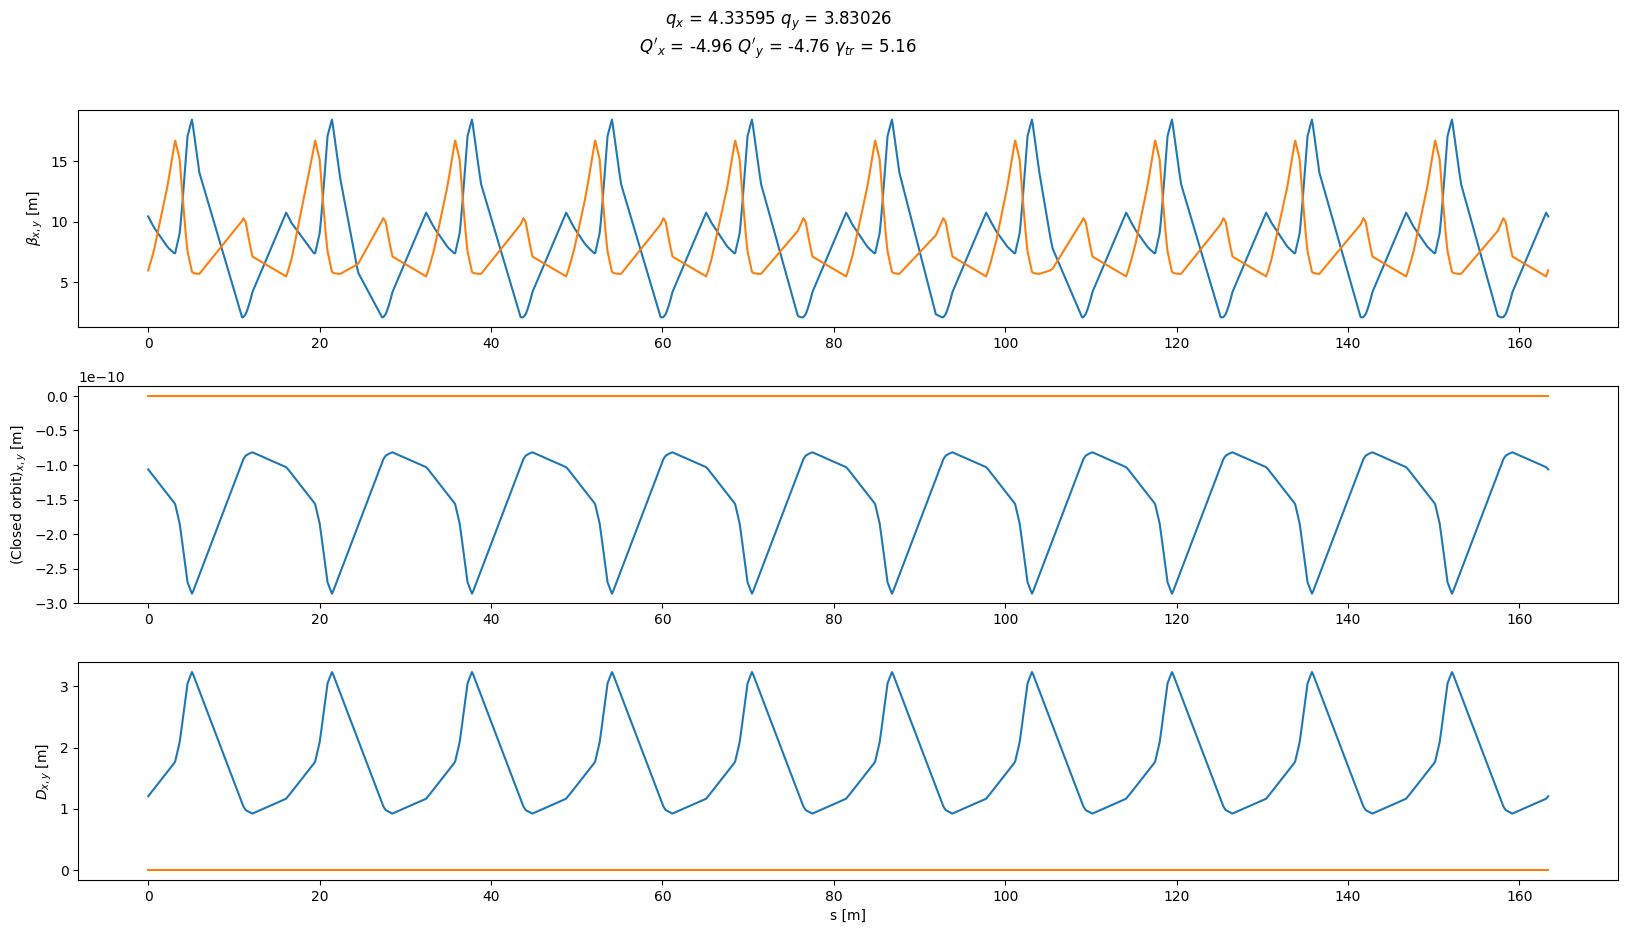

In [14]:
fig1 = plt.figure(1, figsize=(20, 10))
spbet = plt.subplot(3,1,1)
spco = plt.subplot(3,1,2, sharex=spbet)
spdisp = plt.subplot(3,1,3, sharex=spbet)

spbet.plot(twiss.s, twiss.betx)
spbet.plot(twiss.s, twiss.bety)
spbet.set_ylabel(r'$\beta_{x,y}$ [m]')

spco.plot(twiss.s, twiss.x)
spco.plot(twiss.s, twiss.y)
spco.set_ylabel(r'(Closed orbit)$_{x,y}$ [m]')

spdisp.plot(twiss.s, twiss.dx)
spdisp.plot(twiss.s, twiss.dy)
spdisp.set_ylabel(r'$D_{x,y}$ [m]')
spdisp.set_xlabel('s [m]')

fig1.suptitle(
    r'$q_x$ = ' f'{twiss.qx:.5f}' r' $q_y$ = ' f'{twiss.qy:.5f}' '\n'
    r"$Q'_x$ = " f'{twiss.dqx:.2f}' r" $Q'_y$ = " f'{twiss.dqy:.2f}'
    r' $\gamma_{tr}$ = '  f'{1/np.sqrt(twiss.momentum_compaction_factor):.2f}'
)

fig1.subplots_adjust(left=.15, right=.92, hspace=.27)
plt.show()

In [ ]:
emits_x = []
for turn_data_x, turn_data_px in zip(x_tbt.T, px_tbt.T):
    matrix_x = np.cov(turn_data_x, turn_data_px)
    determinant_x = np.linalg.det(matrix_x)
    emits_x.append(np.sqrt(max(0, determinant_x)))
emit_x = np.array(emits_x)

emits_y = []
for turn_data_y, turn_data_py in zip(y_tbt.T, py_tbt.T):
    matrix_y = np.cov(turn_data_y, turn_data_py)
    determinant_y = np.linalg.det(matrix_y)
    emits_y.append(np.sqrt(max(0, determinant_y)))
emit_y = np.array(emits_y)

In [ ]:
plt.plot(emit_x)
plt.show()
plt.plot(emit_y)

In [ ]:
twiss = line.twiss(method='4d')
beta_x_theory = twiss.betx[0] 
alpha_x_theory = twiss.alfx[0]

sig_x2 = np.var(x_tbt.T[0])
sig_xpx = np.cov(x_tbt.T[0], px_tbt.T[0])[0, 1]
curr_emit = emit_x[0]

actual_beta = sig_x2 / curr_emit
actual_alpha = -sig_xpx / curr_emit

print(f"Theory Beta: {beta_x_theory}, Actual: {actual_beta}")